In [2]:
import sys
print(sys.version)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [4]:
import os
import shutil

source = r"C:\Users\HP\Downloads\archive\leapGestRecog"
destination = r"C:\Users\HP\OneDrive\Desktop\HandGestureProject\dataset"

folders = {
    "01_palm": "open_palm",
    "03_fist": "fist",
    "05_thumb": "thumbs_up",
    "06_index": "one_finger",
    "07_ok": "ok"
}

for person in os.listdir(source):
    person_path = os.path.join(source, person)

    if not os.path.isdir(person_path):
        continue

    for original_folder, new_folder in folders.items():
        source_folder = os.path.join(person_path, original_folder)
        destination_folder = os.path.join(destination, new_folder)

        if os.path.exists(source_folder):
            os.makedirs(destination_folder, exist_ok=True)

            for image in os.listdir(source_folder):
                source_image = os.path.join(source_folder, image)
                destination_image = os.path.join(destination_folder, f"{person}_{image}")

                shutil.copy2(source_image, destination_image)

print("Images copied successfully!")


Images copied successfully!


In [5]:
import os

dataset_path = r"C:\Users\HP\OneDrive\Desktop\HandGestureProject\dataset"

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(folder, ":", count, "images")

fist : 2000 images
ok : 2000 images
one_finger : 2000 images
open_palm : 2000 images
thumbs_up : 2000 images


In [6]:
import tensorflow as tf

dataset_path = r"C:\Users\HP\OneDrive\Desktop\HandGestureProject\dataset"

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

print("Classes:", train_data.class_names)

Found 10000 files belonging to 5 classes.
Using 8000 files for training.
Found 10000 files belonging to 5 classes.
Using 2000 files for validation.
Classes: ['fist', 'ok', 'one_finger', 'open_palm', 'thumbs_up']


In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_data = validation_data.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalization completed!")

Normalization completed!


In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(5, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(5, activation='softmax')
])

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [1]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

NameError: name 'model' is not defined

In [ ]:
import tensorflow as tf

dataset_path = r"C:\Users\HP\OneDrive\Desktop\HandGestureProject\dataset"

train_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

print("Dataset loaded successfully!")

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_data = validation_data.map(
    lambda x, y: (normalization_layer(x), y)
)

print("Normalization completed!")



In [ ]:
print(model)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

In [ ]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

In [ ]:
model.save("hand_gesture_model.keras")

print("Model saved successfully!")

In [ ]:
import os

dataset_path = r"C:\Users\HP\OneDrive\Desktop\HandGestureProject\dataset"

for gesture in ['fist', 'ok', 'one_finger', 'open_palm', 'thumbs_up']:
    folder = os.path.join(dataset_path, gesture)
    files = os.listdir(folder)
    print(gesture, "->", files[0])

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = r"C:\Users\HP\OneDrive\Desktop\HandGestureProject\dataset\thumbs_up\00_frame_00_05_0001.png"

img = image.load_img(img_path, target_size=(128, 128))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = ['fist', 'ok', 'one_finger', 'open_palm', 'thumbs_up']

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Gesture:", predicted_class)

In [1]:
import numpy as np
from tensorflow.keras.preprocessing import image
import os

dataset_path = r"C:\Users\HP\OneDrive\Desktop\HandGestureProject\dataset"

class_names = ['fist', 'ok', 'one_finger', 'open_palm', 'thumbs_up']

for gesture in class_names:

    folder = os.path.join(dataset_path, gesture)
    filename = os.listdir(folder)[0]
    img_path = os.path.join(folder, filename)

    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]

    print("Actual:", gesture, "| Predicted:", predicted_class)

NameError: name 'model' is not defined

In [1]:
import tensorflow as tf

model = tf.keras.models.load_model("hand_gesture_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [16]:
import numpy as np
from tensorflow.keras.preprocessing import image
import os

dataset_path = r"C:\Users\HP\OneDrive\Desktop\HandGestureProject\dataset"

class_names = ['fist', 'ok', 'one_finger', 'open_palm', 'thumbs_up']

for gesture in class_names:

    folder = os.path.join(dataset_path, gesture)
    filename = os.listdir(folder)[0]
    img_path = os.path.join(folder, filename)

    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]

    print("Actual:", gesture, "| Predicted:", predicted_class)

Actual: fist | Predicted: fist
Actual: ok | Predicted: ok
Actual: one_finger | Predicted: one_finger
Actual: open_palm | Predicted: open_palm
Actual: thumbs_up | Predicted: thumbs_up


In [17]:
import cv2

cap = cv2.VideoCapture(0)

if cap.isOpened():
    print("Webcam opened successfully!")
else:
    print("Webcam could not be opened.")
    
cap.release()

ModuleNotFoundError: No module named 'cv2'

In [1]:
import cv2

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [2]:
import cv2

cap = cv2.VideoCapture(0)

if cap.isOpened():
    print("Webcam opened successfully!")
else:
    print("Webcam could not be opened.")

cap.release()

Webcam opened successfully!


In [2]:
import tensorflow as tf

model = tf.keras.models.load_model("hand_gesture_model.keras")

print("Model loaded successfully!")

Model loaded successfully!


In [1]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        print("Could not read webcam.")
        break

    cv2.imshow("Hand Gesture Webcam", frame)

    # Press q to close
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

In [2]:
import cv2

cap = cv2.VideoCapture(0)

print("Camera opened:", cap.isOpened())

ret, frame = cap.read()

print("Frame received:", ret)

cap.release()

Camera opened: True
Frame received: True


In [3]:
import cv2

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret:
        print("Could not read webcam.")
        break

    cv2.imshow("Webcam Test", frame)

    # Press Q to close the webcam
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

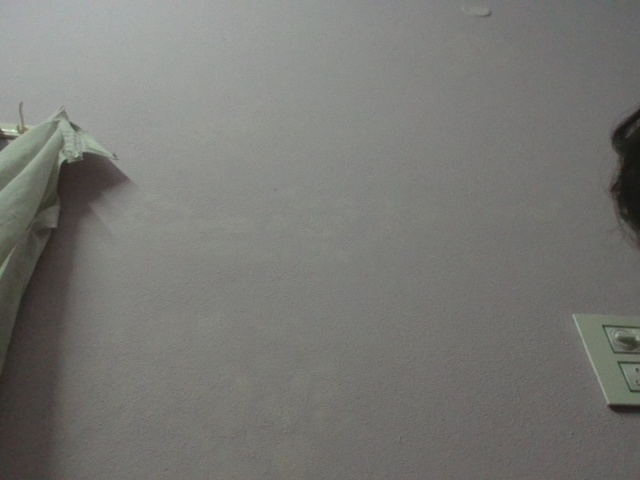

Webcam frame captured successfully!


In [3]:
import cv2
from IPython.display import display, Image
import time

cap = cv2.VideoCapture(0)

ret, frame = cap.read()

if ret:
    cv2.imwrite("webcam_test.jpg", frame)
    display(Image(filename="webcam_test.jpg"))
    print("Webcam frame captured successfully!")
else:
    print("Could not capture webcam frame.")

cap.release()

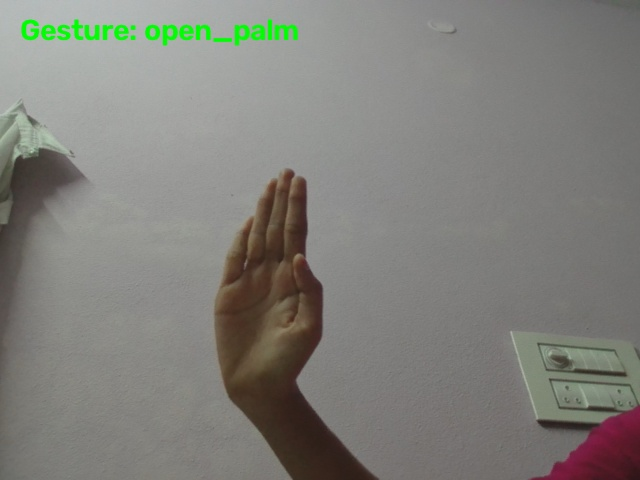

Webcam stopped.


In [4]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output
import time

# Gesture labels
class_names = ['fist', 'ok', 'one_finger', 'open_palm', 'thumbs_up']

# Open webcam
cap = cv2.VideoCapture(0)

print("Starting webcam...")

for i in range(100):
    ret, frame = cap.read()

    if not ret:
        print("Could not read webcam.")
        break

    # Resize frame for model
    img = cv2.resize(frame, (128, 128))

    # Normalize
    img = img / 255.0

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(img, verbose=0)

    # Get predicted class
    predicted_class = np.argmax(prediction[0])

    gesture = class_names[predicted_class]

    # Add gesture text to original frame
    cv2.putText(
        frame,
        "Gesture: " + gesture,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    # Save and display frame
    cv2.imwrite("gesture_frame.jpg", frame)

    clear_output(wait=True)
    display(Image(filename="gesture_frame.jpg"))

    time.sleep(0.1)

cap.release()

print("Webcam stopped.")

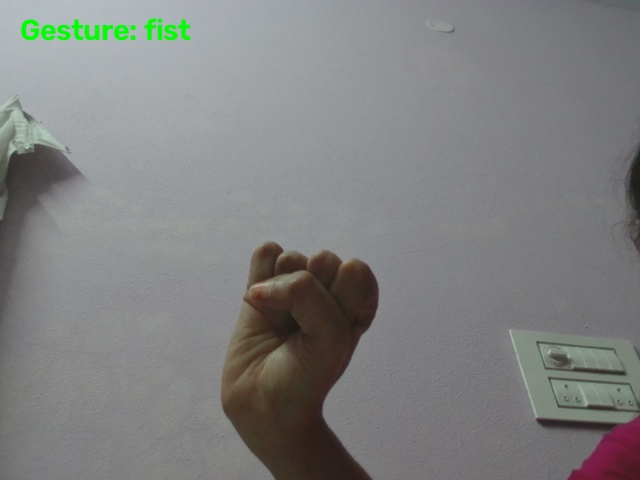

Webcam stopped.


In [6]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output
import time

# Gesture labels
class_names = ['fist', 'ok', 'one_finger', 'open_palm', 'thumbs_up']

# Open webcam
cap = cv2.VideoCapture(0)

print("Starting webcam...")

for i in range(100):
    ret, frame = cap.read()

    if not ret:
        print("Could not read webcam.")
        break

    # Resize frame for model
    img = cv2.resize(frame, (128, 128))

    # Normalize
    img = img / 255.0

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(img, verbose=0)

    # Get predicted class
    predicted_class = np.argmax(prediction[0])

    gesture = class_names[predicted_class]

    # Add gesture text to original frame
    cv2.putText(
        frame,
        "Gesture: " + gesture,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    # Save and display frame
    cv2.imwrite("gesture_frame.jpg", frame)
    clear_output(wait=True)
    display(Image(filename="gesture_frame.jpg"))

    time.sleep(0.1)

cap.release()

print("Webcam stopped.")

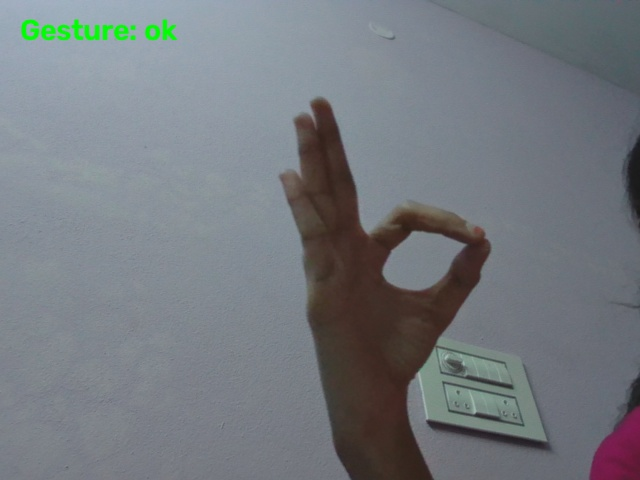

Webcam stopped.


In [12]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output
import time

# Gesture labels
class_names = ['fist', 'ok', 'one_finger', 'open_palm', 'thumbs_up']

# Open webcam
cap = cv2.VideoCapture(0)

print("Starting webcam...")

for i in range(100):
    ret, frame = cap.read()

    if not ret:
        print("Could not read webcam.")
        break

    # Resize frame for model
    img = cv2.resize(frame, (128, 128))

    # Normalize
    img = img / 255.0

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Predict
    prediction = model.predict(img, verbose=0)

    # Get predicted class
    predicted_class = np.argmax(prediction[0])

    gesture = class_names[predicted_class]

    # Add gesture text to original frame
    cv2.putText(
        frame,
        "Gesture: " + gesture,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    # Save and display frame
    cv2.imwrite("gesture_frame.jpg", frame)
    clear_output(wait=True)
    display(Image(filename="gesture_frame.jpg"))

    time.sleep(0.1)

cap.release()

print("Webcam stopped.")

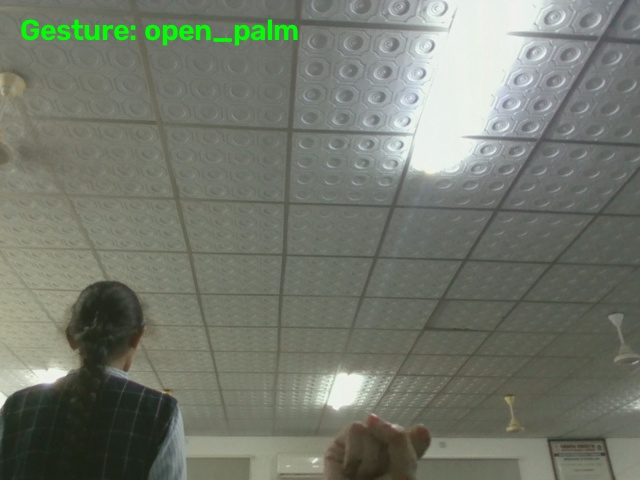

Webcam stopped.


In [6]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output
import time

class_names = ['fist', 'ok', 'one_finger', 'open_palm', 'thumbs_up']

cap = cv2.VideoCapture(0)

for i in range(100):
    ret, frame = cap.read()

    if not ret:
        print("Could not read webcam.")
        break

    # Convert OpenCV BGR image to RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Resize to model input size
    img = cv2.resize(rgb_frame, (128, 128))

    # Normalize pixel values
    img = img.astype("float32") / 255.0

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Prediction
    prediction = model.predict(img, verbose=0)

    predicted_class = np.argmax(prediction[0])
    gesture = class_names[predicted_class]

    # Display prediction
    cv2.putText(
        frame,
        "Gesture: " + gesture,
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.imwrite("gesture_frame.jpg", frame)

    clear_output(wait=True)
    display(Image(filename="gesture_frame.jpg"))

    time.sleep(0.1)

cap.release()


print("Webcam stopped.")

In [20]:
print("Class names:")
print(class_names)

print("\nModel output shape:")
print(model.output_shape)

Class names:
['fist', 'ok', 'one_finger', 'open_palm', 'thumbs_up']

Model output shape:
(None, 5)


In [21]:
import os
import matplotlib.pyplot as plt

folder = "one_finger"

files = os.listdir(folder)

print("Number of images:", len(files))
print("First 5 files:", files[:5])

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'one_finger'

In [22]:
import os

print("Current Jupyter folder:")
print(os.getcwd())

print("\nFolders/files here:")
print(os.listdir())

Current Jupyter folder:
C:\Users\HP

Folders/files here:
['.conda', '.continuum', '.copilot', '.docker', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.python_history', '.vscode', '.vscode-shared', 'aitraining.ipynb', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'DAY2 _P2.ipynb', 'DAY5.ipynb', 'DAY6 PART2ipynb', 'DAY6 _P2.ipynb', 'DAY6.ipynb', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'first_program.py', 'gesture_frame.jpg', 'hand_gestures_project.ipynb', 'hand_gesture_model.keras', 'input_output.py', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{78ce6374-01bf-11f0-adb3-388d3d563d6b}.TM.blf', 'NTUSER.DAT{78ce6374-01bf-11f0-adb3-388d3d563d6b}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{78ce6374-01bf-11f0-adb3-388d3d563d6b}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'PyCharmMiscProject', '

In [24]:
import os

search_path = r"C:\Users\HP"

for root, dirs, files in os.walk(search_path):
    # Skip system folders to make the search faster
    dirs[:] = [d for d in dirs if d not in [
        'AppData', 'Application Data', 'Cookies',
        'Local Settings', 'OneDrive'
    ]]

    if "one_finger" in dirs:
        print("Dataset found!")
        print("Location:", os.path.join(root, "one_finger"))
        break

In [4]:
import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = r"C:\Users\HP\OneDrive\Desktop\HandGestureProject\dataset"
folder = os.path.join(dataset_path, "one_finger")

files = os.listdir(folder)

print("Number of one_finger images:", len(files))
print("First 5 files:", files[:5])

Number of one_finger images: 2000
First 5 files: ['00_frame_00_06_0001.png', '00_frame_00_06_0002.png', '00_frame_00_06_0003.png', '00_frame_00_06_0004.png', '00_frame_00_06_0005.png']


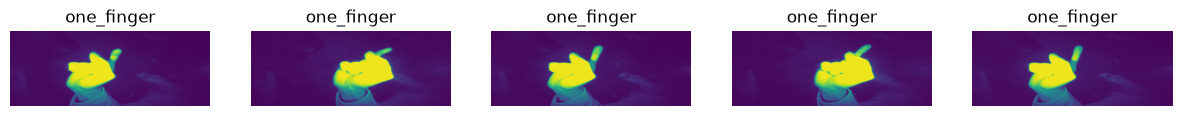

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    img = Image.open(os.path.join(folder, files[i]))
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title("one_finger")

plt.show()